In [1]:
import numpy as np
import h5py as h5
import matplotlib.pyplot as plt

In [2]:
hfile = h5.File("/home/plotnikovgp/baikal/data/mc_baikal_norm_cut-8_ordered_with_MCarlo.h5", "r")

In [3]:
# %matplotlib widget

In [3]:
hfile['train/data'].shape # .shape # [0]

(1365465, 35, 5)

In [4]:
1365465 / 1e6

1.365465

In [5]:
!ls /home/plotnikovgp/baikal/data/

baikal_mc2020_multi_split_0924_MChits-8-2_normed.h5
baikal_multi_0324_flat_treck-cascade_h8_s2_pureMC.h5
baikal_multi_0324_flat_treck-cascade_h8_s2_pureMC_normed-2strings.h5
baikal_multi_0324_flat_treck-cascade_h8_s2_pureMC_normed-3strings-10hits.h5
baikal_multi_0324_flat_treck-cascade_h8_s2_pureMC_normed.h5
mc_baikal_norm_cut-8_ordered_with_MCarlo.h5


In [6]:
hfile2 = h5.File("/home/plotnikovgp/baikal/data/baikal_multi_0324_flat_treck-cascade_h8_s2_pureMC_normed.h5", "r")

In [7]:
hfile2['train/'].keys()

<KeysViewHDF5 ['channels', 'data', 'ev_ids', 'ev_starts', 'labels', 'muons_prty', 'num_un_strings', 'prime_prty', 't_res']>

In [8]:
hfile2['test/data/data'].shape

(37561563, 5)

In [9]:
37561563 / 1e6

37.561563

In [10]:
angles = np.array(hfile2['test/prime_prty/data'])

In [18]:
hfile['test'].keys()

<KeysViewHDF5 ['data', 'ev_chars', 'ev_ids', 'labels_full', 'labels_num_mu', 'labels_one_mu', 'labels_particle', 'labels_signal_noise', 'labels_track_type', 'mask']>

In [29]:
thetha = angles[::5, 0]

thetha2 = np.array(hfile['val/ev_chars'])[:, 0]

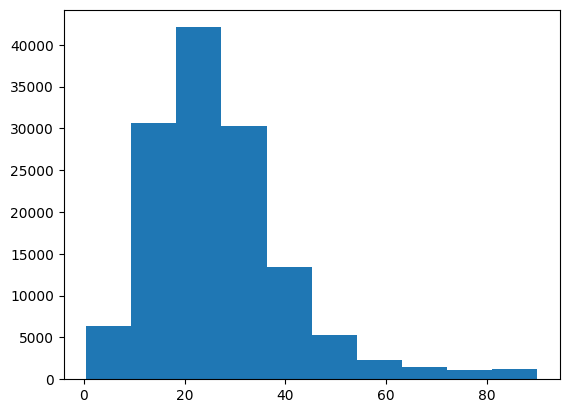

In [30]:
plt.hist(thetha2)
plt.show()
pass

In [22]:
angles.shape

(1429154, 6)

In [ ]:
plt.plot(

In [4]:
max_len = 0
idx = 0
for i in range(10000):
    start, end = hfile["test/ev_starts/data"][i: i + 2]
    if end - start > max_len:
        max_len = end - start
        idx = i
max_len, idx

(103, 7346)

In [5]:
# idx = 35
start, end = hfile["test/ev_starts/data"][idx: idx + 2]
event_feats = hfile['test/data/data'][start:end]
event_labels = hfile["test/labels/data"][start:end]
event_labels[event_labels > 0] = 1 # cascade
event_labels[event_labels < 0] = 0 # track
markers = np.array(['g'] * len(event_labels))
markers[event_labels == 0] = 'b'

In [6]:
event_labels

array([0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0], dtype=int32)

In [7]:
event_labels.shape

(103,)

In [8]:
# ?ax.scatter

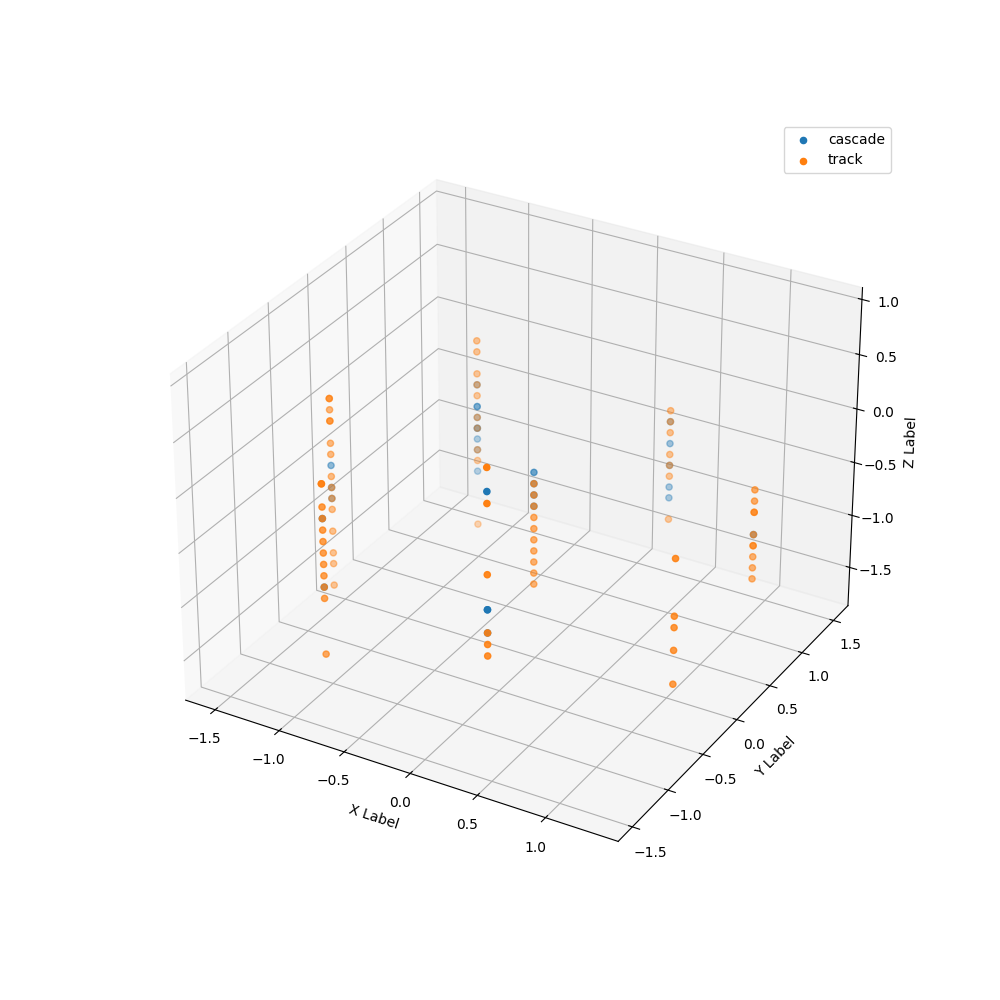

In [9]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

x, y, z = event_feats[:, 2], event_feats[:, 3], event_feats[:, 4]
mask = event_labels.astype(bool)
ax.scatter(x[mask], y[mask], z[mask], label="cascade")
mask = ~mask
ax.scatter(x[mask], y[mask], z[mask], label="track")

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
ax.legend()